In [17]:
import math
import os
import uuid
import time

from matplotlib import cm
import matplotlib.animation as anim
import matplotlib.pyplot as plt

import numpy as np
import tensorflow as tf
from pathlib import Path

from google.protobuf import text_format
from waymo_open_dataset.metrics.ops import py_metrics_ops
from waymo_open_dataset.metrics.python import config_util_py as config_util
from waymo_open_dataset.protos import motion_metrics_pb2
from waymo_open_dataset.protos import scenario_pb2
from waymo_open_dataset.utils.sim_agents import visualizations
from waymo_open_dataset.utils.sim_agents import submission_specs
from waymo_open_dataset.utils import range_image_utils



In [13]:
data_dir = Path("../data/waymo_motion_v1_3_0/scenario/")
TRAIN_FILES = os.path.join(data_dir, 'training', 'training.tfrecord*')
VALIDATION_FILES = os.path.join(data_dir, 'validation', 'validation.tfrecord*')
TEST_FILES = os.path.join(data_dir, 'testing', 'testing.tfrecord*')

In [ ]:
test_files = tf.io.gfile.glob(TRAIN_FILES)
train_set = tf.data.TFRecordDataset(test_files, compression_type='')
train_iter = train_set.as_numpy_iterator()
#get train set length
print(f'Train set length: {train_set_length}')

KeyboardInterrupt: 

In [77]:
scenario = scenario_pb2.Scenario.FromString(next(train_iter))
print(f'Checking type: {type(scenario)}')
print(f'Loaded scenario with ID: {scenario.scenario_id}')


Checking type: <class 'waymo_open_dataset.protos.scenario_pb2.Scenario'>
Loaded scenario with ID: d328dfbacbd5ba86


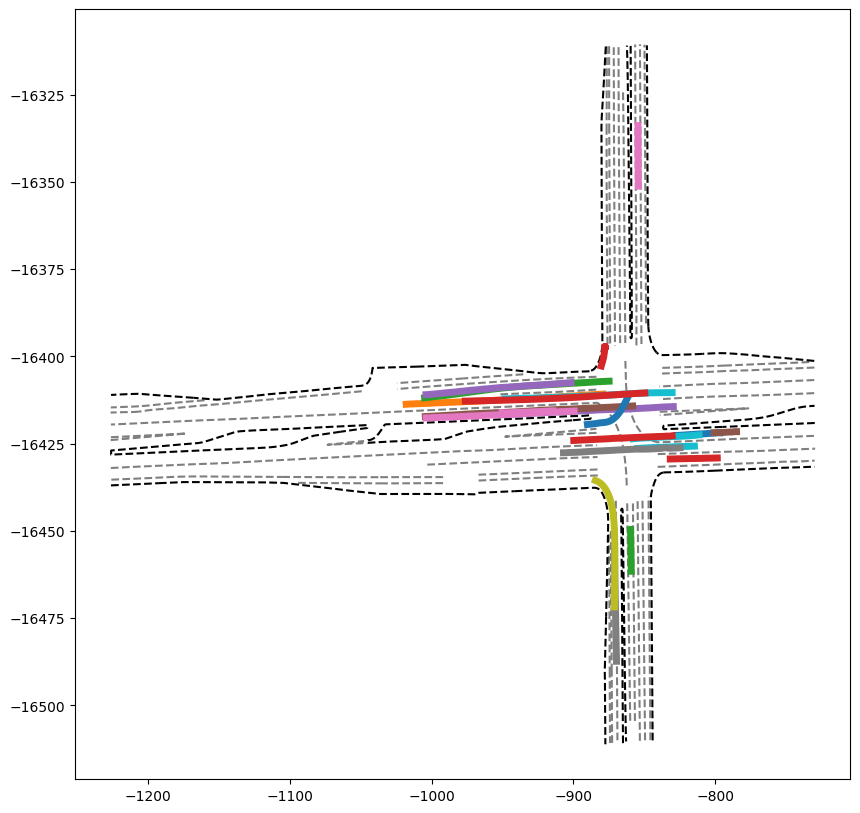

In [78]:
def plot_track_trajectory(track: scenario_pb2.Track) -> None:
  valids = np.array([state.valid for state in track.states])
  if np.any(valids):
    x = np.array([state.center_x for state in track.states])
    y = np.array([state.center_y for state in track.states])
    ax.plot(x[valids], y[valids], linewidth=5)


# Plot their tracks.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
visualizations.add_map(ax, scenario)

for track in scenario.tracks:
  if track.id in submission_specs.get_sim_agent_ids(
      scenario
  ):
    plot_track_trajectory(track)

plt.show()

In [6]:
plt.rcParams.get('figure.figsize')

[6.4, 4.8]

In [ ]:
scenario.

[id: 1
road_line {
  type: TYPE_BROKEN_SINGLE_WHITE
  polyline {
    x: 5238.008187563794
    y: 11095.472932333445
    z: -46.164596055364484
  }
  polyline {
    x: 5237.508338286019
    y: 11095.468962312098
    z: -46.16590831122386
  }
  polyline {
    x: 5237.008488989734
    y: 11095.464994637632
    z: -46.167220567083234
  }
  polyline {
    x: 5236.508639667008
    y: 11095.461030236036
    z: -46.16853282294261
  }
  polyline {
    x: 5236.008790311227
    y: 11095.457070032506
    z: -46.169845078801984
  }
  polyline {
    x: 5235.508940915782
    y: 11095.45311495303
    z: -46.17115733466136
  }
  polyline {
    x: 5235.009091471418
    y: 11095.449165922017
    z: -46.172469590520734
  }
  polyline {
    x: 5234.509241971526
    y: 11095.445223865452
    z: -46.17378184638011
  }
  polyline {
    x: 5234.009392410814
    y: 11095.441289709324
    z: -46.175094102239484
  }
  polyline {
    x: 5233.50954278003
    y: 11095.437364379619
    z: -46.17640635809886
  }
  pol